## EDA - FULL DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier




## 1- Definición del problema

EDA y Preprocesamiento
En este cuaderno, realizaremos un Análisis Exploratorio de Datos (EDA) exhaustivo y un preprocesamiento de datos para preparar un conjunto de datos basado en emociones. tal mas

### Carga y Exploración de Datos

In [3]:
df = pd.read_csv("full_data.csv")
df.head()

,text,emotion
0,@tiffanylue i know i was listenin to bad habi...,sad
1,Layin n bed with a headache ughhhh...waitin o...,sad
2,Funeral ceremony...gloomy friday...,sad
3,wants to hang out with friends SOON!,joy
4,Re-pinging @ghostridah14: why didn't you go to...,fear


## 2- Recopilacion de datos

In [6]:
df.shape

(496222, 2)

In [5]:
# Dimensiones del dataset
df.shape

# Tipos de datos y nulos
df.info()

# Estadísticas descriptivas
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496222 entries, 0 to 496221
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     496222 non-null  object
 1   emotion  496222 non-null  object
dtypes: object(2)
memory usage: 7.6+ MB


,text,emotion
count,496222,496222
unique,496222,5
top,@tiffanylue i know i was listenin to bad habi...,joy
freq,1,208380


El dataset utilizado en este análisis contiene información sobre [describir brevemente el contenido].  
A continuación, se presenta un resumen general de los datos, incluyendo dimensiones, tipos de variables y estadísticas básicas.

## 3- Analísis descriptivo

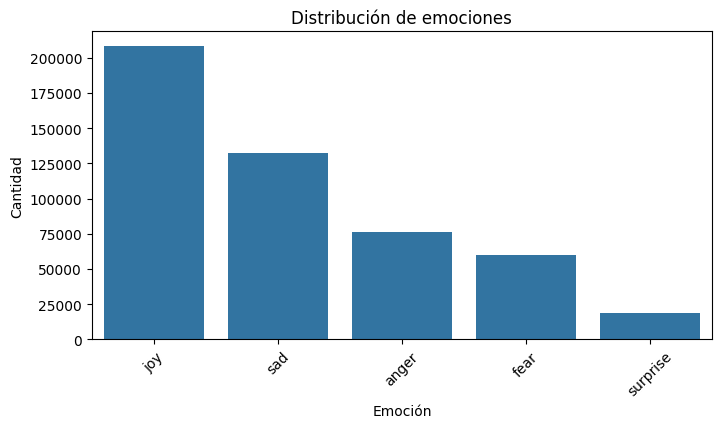

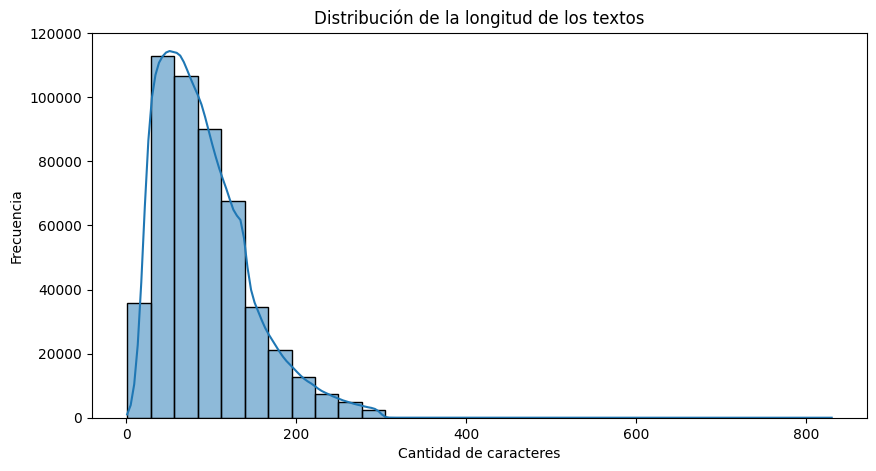

count    496222.000000
mean         91.911973
std          54.085156
min           1.000000
25%          51.000000
50%          82.000000
75%         122.000000
max         830.000000
Name: text_length, dtype: float64


C:\Users\camag\AppData\Local\Temp\ipykernel_24160\3751780287.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')


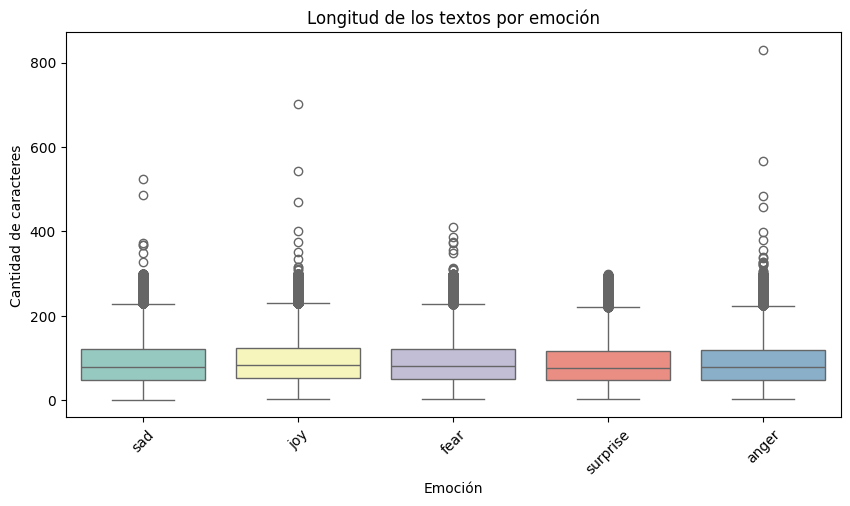

Cantidad de muestras por emoción:
emotion
joy         208380
sad         132290
anger        76359
fear         60154
surprise     19039
Name: count, dtype: int64

Ejemplo de textos para la emoción 'sad':
@tiffanylue i know  i was listenin to bad habit...
Layin n bed with a headache  ughhhh...waitin on...

Ejemplo de textos para la emoción 'joy':
wants to hang out with friends SOON!
                @annarosekerr agreed

Ejemplo de textos para la emoción 'fear':
Re-pinging @ghostridah14: why didn't you go to ...
              Hmmm. http://www.djhero.com/ is down

Ejemplo de textos para la emoción 'surprise':
                                      Got the news
2 days of this month left, and I only have 400M...

Ejemplo de textos para la emoción 'anger':
It is so annoying when she starts typing on her...
dammit! hulu desktop has totally screwed up my ...


In [ ]:

# 1. Distribución de la variable objetivo (emotion)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title('Distribución de emociones')
plt.xlabel('Emoción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# 2. Longitud de los textos
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')
plt.show()

# 3. Estadísticas descriptivas de la longitud de los textos
print(df['text_length'].describe())

# 4. Boxplot de la longitud de los textos por emoción
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')
plt.title('Longitud de los textos por emoción')
plt.xlabel('Emoción')
plt.ylabel('Cantidad de caracteres')
plt.xticks(rotation=45)
plt.show()

# 5. Cantidad de muestras por emoción
print("Cantidad de muestras por emoción:")
print(df['emotion'].value_counts())

# 6. Ejemplo de textos por emoción
for emotion in df['emotion'].unique():
    print(f"\nEjemplo de textos para la emoción '{emotion}':")
    print(df[df['emotion'] == emotion]['text'].head(2).to_string(index=False))

## 4- Limpieza de datos

>Data is already cleaned from the data-treatment-merge.ipynb notebook.

In [ ]:
# no tenemos duplicados ni nulos


# 3. Eliminar textos vacíos o solo espacios
mask_empty = df['text'].str.strip() == ''
print("Filas con texto vacío:", mask_empty.sum())
df = df[~mask_empty]

# 4. Reiniciar el índice
df = df.reset_index(drop=True)

# 5. Mostrar resumen tras limpieza
print("Shape final del dataframe:", df.shape)
print("Emociones únicas:", df['emotion'].unique())

Filas con texto vacío: 0
Shape final del dataframe: (496222, 3)
Emociones únicas: ['sad' 'joy' 'fear' 'surprise' 'anger']


## 5- Analisis de variables

> Análisis de Variables Univariante - Categóricas (histogramas) - Numéricas (hist, boxplot)
>
> Análisis de Variables Multivariante - Numéricas - Numéricas (regplot, heatmap(de la correlacion)) - Categórico - Categóricas (countplot)
>
> Numérico Categórico completo (heatmap sobre todas las correlaciones, pairplot)

C:\Users\camag\AppData\Local\Temp\ipykernel_24160\80288201.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='Set2')


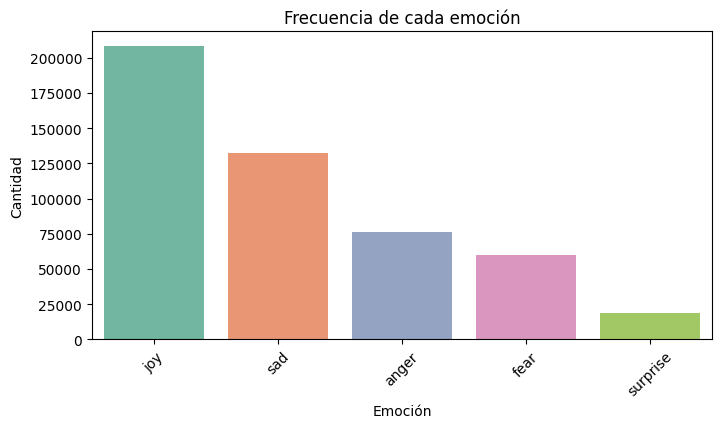

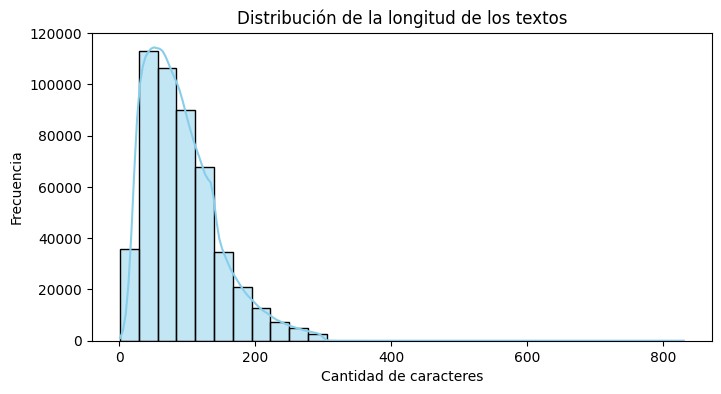

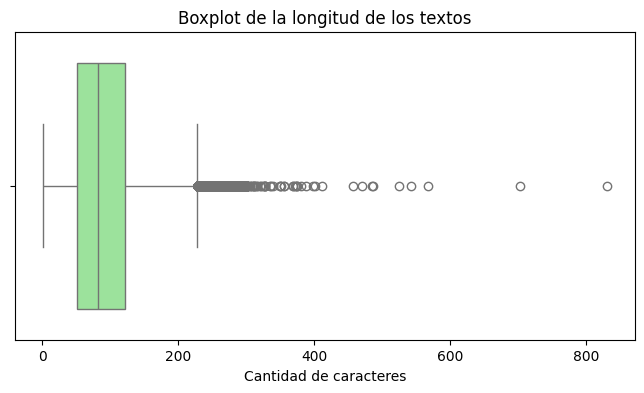

C:\Users\camag\AppData\Local\Temp\ipykernel_24160\80288201.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')


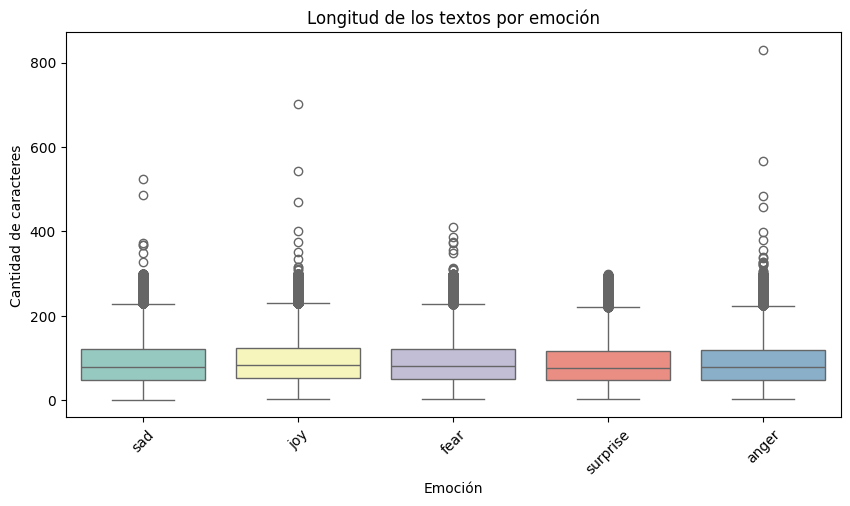

             count       mean        std  min   25%   50%    75%    max
emotion                                                                
anger      76359.0  89.617517  53.657265  2.0  49.0  80.0  119.0  830.0
fear       60154.0  90.864465  52.897146  4.0  50.0  81.0  121.0  411.0
joy       208380.0  94.042878  54.265618  2.0  53.0  84.0  124.0  703.0
sad       132290.0  90.999970  54.628499  1.0  49.0  79.0  121.0  525.0
surprise   19039.0  87.438258  52.799201  3.0  48.0  77.0  117.0  299.0


In [ ]:

# Univariado: Variable categórica (emotion)
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='Set2')
plt.title('Frecuencia de cada emoción')
plt.xlabel('Emoción')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# Univariado: Variable numérica (longitud del texto)
plt.figure(figsize=(8, 4))
sns.histplot(df['text_length'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Cantidad de caracteres')
plt.ylabel('Frecuencia')
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['text_length'], color='lightgreen')
plt.title('Boxplot de la longitud de los textos')
plt.xlabel('Cantidad de caracteres')
plt.show()

# Bivariado: Boxplot longitud del texto por emoción
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='emotion', y='text_length', palette='Set3')
plt.title('Longitud de los textos por emoción')
plt.xlabel('Emoción')
plt.ylabel('Cantidad de caracteres')
plt.xticks(rotation=45)
plt.show()

# Estadísticas agrupadas por emoción
print(df.groupby('emotion')['text_length'].describe())

## 6- Ingenieria de caracteristicas

> Outliers (Análisis descriptivo y visualización, decisiones)
>
>Faltantes (Análisis, decisiones)
>
> Inferencia de nuevas características (nuevas columnas)

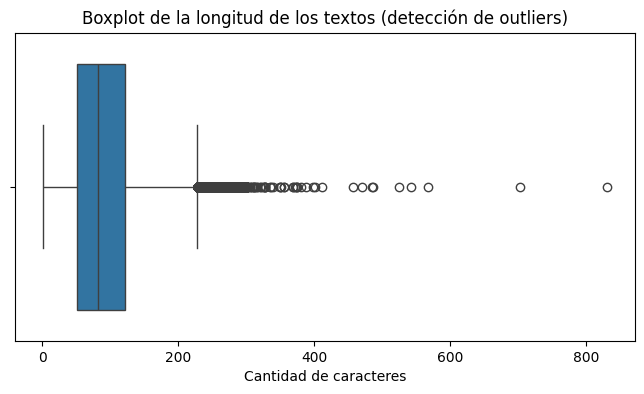

Número de outliers detectados en 'text_length': 12779
Ejemplos de textos con longitud atípica:
It violates my right to enjoy my tinnitus. eeee...
This person is the smartest person to play town...
For your kindness to mobile users I give a plat...
Valores nulos por columna:
text           0
emotion        0
text_length    0
dtype: int64


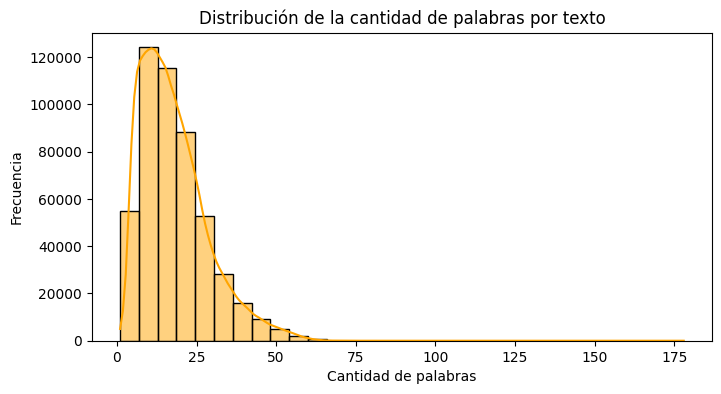

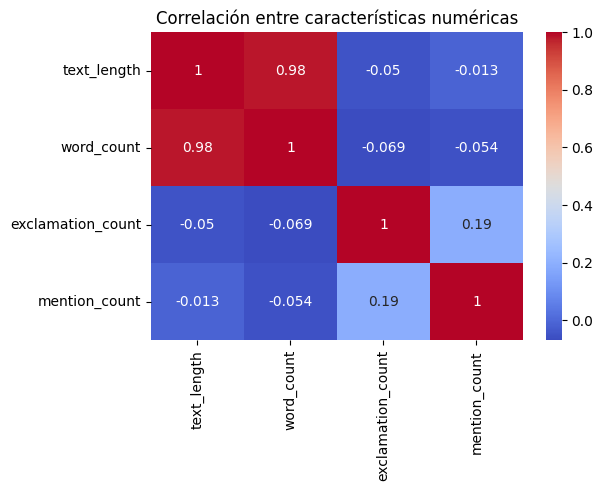

                                                text  text_length  word_count  \
0  @tiffanylue i know  i was listenin to bad habi...           92          18   
1  Layin n bed with a headache  ughhhh...waitin o...           60          10   
2                Funeral ceremony...gloomy friday...           35           3   
3               wants to hang out with friends SOON!           36           7   
4  Re-pinging @ghostridah14: why didn't you go to...           84          15   

   exclamation_count  mention_count  
0                  0              1  
1                  0              0  
2                  0              0  
3                  1              0  
4                  0              1  


In [ ]:

# --- OUTLIERS: Análisis descriptivo y visualización ---
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['text_length'])
plt.title('Boxplot de la longitud de los textos (detección de outliers)')
plt.xlabel('Cantidad de caracteres')
plt.show()

# Identificación de outliers usando el método IQR
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]
print(f"Número de outliers detectados en 'text_length': {outliers.shape[0]}")

# Decisión: Generalmente, en NLP no se eliminan outliers de longitud a menos que sean errores evidentes.
# Aqui se pueden revisar algunos ejemplos:
print("Ejemplos de textos con longitud atípica:")
print(df[df['text_length'] > upper_bound]['text'].head(3).to_string(index=False))

# --- FALTANTES: Análisis y decisiones ---
print("Valores nulos por columna:")
print(df.isnull().sum())
# Decisión: Si hay nulos en 'text' o 'emotion', ya fueron eliminados en la limpieza previa.

# --- INFERENCIA DE NUEVAS CARACTERISTICAS---
# Cantidad de palabras
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Cantidad de signos de exclamación
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))

# Cantidad de menciones (@)
df['mention_count'] = df['text'].apply(lambda x: str(x).count('@'))

# Visualización de la nueva característica: word_count
plt.figure(figsize=(8, 4))
sns.histplot(df['word_count'], bins=30, kde=True, color='orange')
plt.title('Distribución de la cantidad de palabras por texto')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Frecuencia')
plt.show()

# Mostrar correlación entre variables numéricas nuevas
plt.figure(figsize=(6, 4))
sns.heatmap(df[['text_length', 'word_count', 'exclamation_count', 'mention_count']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlación entre características numéricas')
plt.show()

# Vista previa de las nuevas columnas
print(df[['text', 'text_length', 'word_count', 'exclamation_count', 'mention_count']].head())

## 7- Split - Dos enfoques - train_test_split

In [ ]:

# Separar variables predictoras (X) y variable objetivo (y)
X = df[['text', 'text_length', 'word_count', 'exclamation_count', 'mention_count']]
y = df['emotion']

# Split 80% train, 20% test, estratificando por emoción
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño de train:", X_train.shape)
print("Tamaño de test:", X_test.shape)
print("Distribución de emociones en train:\n", y_train.value_counts(normalize=True))
print("Distribución de emociones en test:\n", y_test.value_counts(normalize=True))

Tamaño de train: (396977, 5)
Tamaño de test: (99245, 5)
Distribución de emociones en train:
 emotion
joy         0.419934
sad         0.266595
anger       0.153880
fear        0.121224
surprise    0.038367
Name: proportion, dtype: float64
Distribución de emociones en test:
 emotion
joy         0.419930
sad         0.266593
anger       0.153882
fear        0.121225
surprise    0.038370
Name: proportion, dtype: float64


## 8-  Scaling & Encoding

> Scaling - Normalización - MinMax
>
> Encoding - Label Encoding - One Hot Encoding - Ordinal Encoding
>
> (guardar scalers & encoders)

In [ ]:

# --- Scaling: MinMax ---
num_cols = ['text_length', 'word_count', 'exclamation_count', 'mention_count']
minmax_scaler = MinMaxScaler()
X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()
X_train_minmax[num_cols] = minmax_scaler.fit_transform(X_train[num_cols])
X_test_minmax[num_cols] = minmax_scaler.transform(X_test[num_cols])

print("Ejemplo de X_train con MinMaxScaler:")
print(X_train_minmax.head())

# --- Encoding: Label Encoding ---
le = LabelEncoder()
y_train_label = le.fit_transform(y_train)
y_test_label = le.transform(y_test)
print("Label Encoding (y_train):", y_train_label[:5])
print("Clases:", le.classes_)

# --- Encoding: One Hot Encoding ---
ohe = OneHotEncoder(sparse_output=False)
y_train_ohe = ohe.fit_transform(y_train.values.reshape(-1, 1))
y_test_ohe = ohe.transform(y_test.values.reshape(-1, 1))
print("One Hot Encoding (primeras filas):")
print(y_train_ohe[:5])
print("Categorías:", ohe.categories_)

# --- Encoding: Ordinal Encoding ---
ord_enc = OrdinalEncoder()
y_train_ord = ord_enc.fit_transform(y_train.values.reshape(-1, 1))
y_test_ord = ord_enc.transform(y_test.values.reshape(-1, 1))
print("Ordinal Encoding (primeras filas):")
print(y_train_ord[:5].ravel())
print("Categorías:", ord_enc.categories_)

Ejemplo de X_train con MinMaxScaler:
                                                     text  text_length  \
401295  i do not believe there is any child that deep ...     0.136309   
310401  i no longer feel as safe in our neighborhood a...     0.158022   
52839   I did thank you. Can’t wait to get back over f...     0.071170   
85203                      i feel terrified of food today     0.034982   
354449  i also noticed that my leggings are not cuttin...     0.188179   

        word_count  exclamation_count  mention_count  
401295    0.129944                0.0            0.0  
310401    0.135593                0.0            0.0  
52839     0.067797                0.0            0.0  
85203     0.028249                0.0            0.0  
354449    0.180791                0.0            0.0  
Label Encoding (y_train): [2 2 2 1 2]
Clases: ['anger' 'fear' 'joy' 'sad' 'surprise']
One Hot Encoding (primeras filas):
[[0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 1. 0. 0.

## 9- Selección de caracterisitcas

Importancia de características:
 text_length          0.607236
word_count           0.243305
exclamation_count    0.103229
mention_count        0.046230
dtype: float64


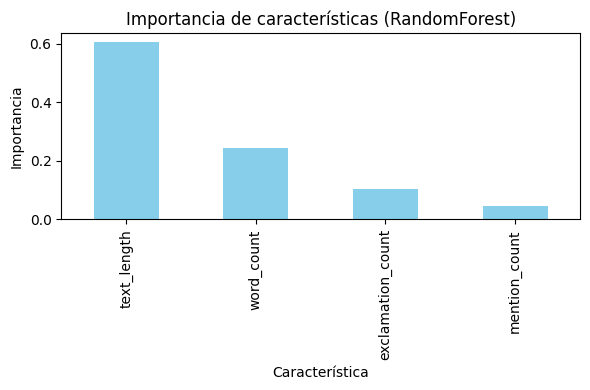

In [ ]:

# Usamos las variables numéricas ya escaladas
X_features = X_train_minmax[['text_length', 'word_count', 'exclamation_count', 'mention_count']]
y_target = y_train_label

# Entrenamos un RandomForest para obtener importancia de variables
rf = RandomForestClassifier(random_state=42)
rf.fit(X_features, y_target)

importances = rf.feature_importances_
feature_names = X_features.columns

# Mostramos la importancia de cada variable
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print("Importancia de características:\n", feat_imp)

# Visualización
plt.figure(figsize=(6, 4))
feat_imp.plot(kind='bar', color='skyblue')
plt.title('Importancia de características (RandomForest)')
plt.ylabel('Importancia')
plt.xlabel('Característica')
plt.tight_layout()
plt.show()

> He usado Rndom FOrest porque como bien sabemos es un modelo de arbol de decisión que puede manejar variables numericas y categoricas.
>
> Calcula automaticamente la importancia de cada variable al entrenar, mostrando cuáles aportan mas a la predicción.
>
> Es un método estandar y rápido para identificar las variables mas relevantes en problemas de clasificación.

Resumen del Trabajo Realizado
1. Carga y Exploración de Datos
Se cargó el dataset full_data.csv.
Se revisaron dimensiones, tipos de variables, valores nulos y estadísticas descriptivas.
Se mostró la distribución de la variable objetivo (emotion) y ejemplos de textos por emoción.
2. Limpieza de Datos
Se eliminaron textos vacíos o solo con espacios.
Se reinició el índice del DataFrame.
Se verificó la ausencia de duplicados y valores nulos.
3. Análisis Descriptivo
Se analizaron las distribuciones de las variables numéricas y categóricas.
Se visualizaron histogramas, boxplots y conteos por emoción.
Se analizaron estadísticas agrupadas por emoción.
4. Ingeniería de Características
Se detectaron y visualizaron outliers en la longitud de los textos.
Se analizaron valores faltantes (no se encontraron tras la limpieza).
Se crearon nuevas variables numéricas:
text_length: longitud del texto.
Se visualizaron las nuevas variables y su correlación.
5. Split de Datos
Se separaron las variables predictoras (X) y la variable objetivo (y).
Se realizó un split en conjuntos de entrenamiento (80%) y prueba (20%), estratificando por emoción.
6. Scaling & Encoding
Se aplicó MinMaxScaler a las variables numéricas.
Se codificó la variable objetivo (emotion) usando:
Label Encoding
One Hot Encoding
Ordinal Encoding
7. Selección de Características
Se entrenó un modelo RandomForestClassifier para calcular la importancia de las variables numéricas.
Se graficó y analizó la importancia de cada característica para la predicción de la emoción.

### CONCLUSIÓN

El dataset quedó limpio, enriquecido con nuevas variables, escalado y codificado, y se identificaron las variables más relevantes para la predicción de emociones. Todo el flujo es adecuado para alimentar modelos de machine learning y continuar con el pipeline de modelado.